设备: cpu
输出目录: results_cnn_gru_EWS_5min/

数据维度: (59146, 113)
时间范围: 2019-07-01 13:25:00 ~ 2021-06-30 23:55:00
正样本数: 1417  (2.40%)
  ✓ market组加入: ['is_official_halt_lag1', 'is_official_halt_lag2']

  Ablation 实验

  baseline_market  (31 特征)
    train=41,804  pos=745  test=3,759  pos=252
    pos_weight=55.1
    Epoch   5/20  loss=1.2396
    Epoch  10/20  loss=1.1765
    Epoch  15/20  loss=1.1235
    Epoch  20/20  loss=1.0770
    PR-AUC=0.1790  ROC-AUC=0.7423  F1=0.1767  Recall=0.8095

  M1_add_cascade  (43 特征)
    train=41,804  pos=745  test=3,759  pos=252
    pos_weight=55.1
    Epoch   5/20  loss=1.2395
    Epoch  10/20  loss=1.1800
    Epoch  15/20  loss=1.1157
    Epoch  20/20  loss=1.0797
    PR-AUC=0.1820  ROC-AUC=0.7274  F1=0.1594  Recall=0.8373

  M2_add_network  (53 特征)
    train=41,804  pos=745  test=3,759  pos=252
    pos_weight=55.1
    Epoch   5/20  loss=1.2191
    Epoch  10/20  loss=1.1395
    Epoch  15/20  loss=1.0424
    Epoch  20/20  loss=1.0230
    PR-AUC=0.2025  ROC-AUC=0

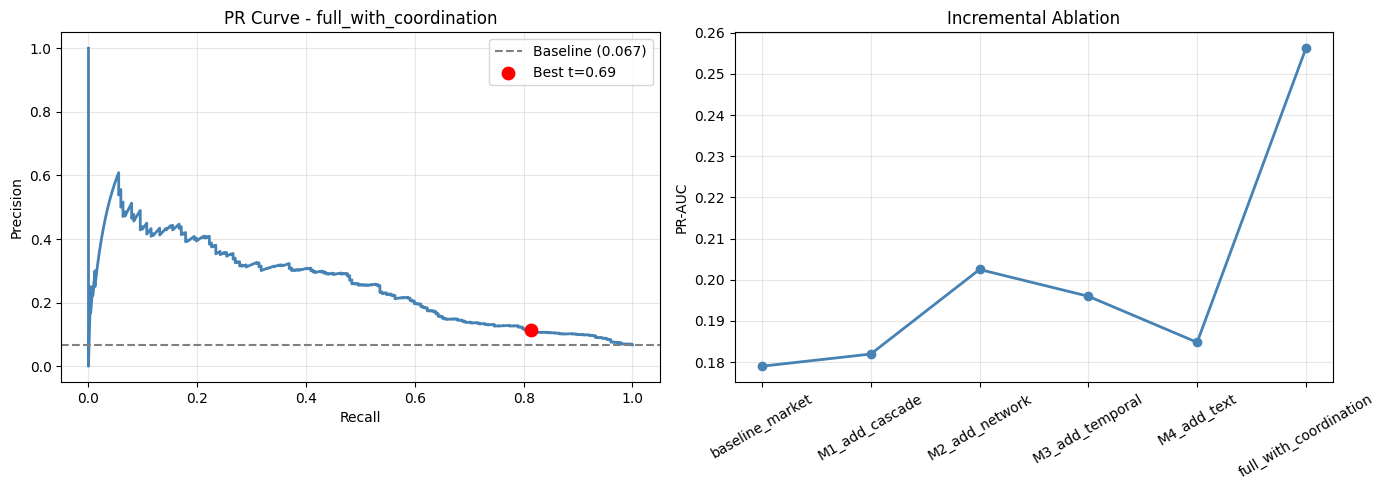


✓ 所有文件已保存到: results_cnn_gru_EWS_5min/


In [9]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import torch
torch.cuda.is_available = lambda: False  # 强制禁用CUDA

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score,
                             classification_report, precision_recall_curve)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ─── 配置 ────────────────────────────────────────────────────────────────────
DATA_FILE   = 'data/merged_data_scaled_CLEAN.parquet'
GROUPS_FILE = 'data/feature_groups_CLEAN.json'
TARGET      = 'EWS_5min'   # <- 改成 EWS_15min / EWS_30min

SEQ_LEN    = 12    # 过去12个bar = 60分钟
BATCH_SIZE = 512
EPOCHS     = 20
LR         = 1e-3
DEVICE     = 'cpu'

TRAIN_END  = '2021-01-25 23:59:59'
TEST_START = '2021-01-28 00:00:00'
TEST_END   = '2021-02-28 23:59:59'

LEAKAGE_FEATURES = [
    'is_episode_t', 'is_luld', 'is_anomaly',
    'is_price_spike', 'is_volume_surge',
    'thread_concentration', 'is_official_halt',
]

OUT_DIR = f'results_cnn_gru_{TARGET}'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'设备: {DEVICE}')
print(f'输出目录: {OUT_DIR}/')

# ─── 1. 加载数据 ─────────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_FILE)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

with open(GROUPS_FILE, 'r') as f:
    feature_groups = json.load(f)

print(f"\n数据维度: {df.shape}")
print(f"时间范围: {df['timestamp'].min()} ~ {df['timestamp'].max()}")
print(f"正样本数: {int(df[TARGET].sum())}  ({df[TARGET].mean()*100:.2f}%)")

# 官方halt滞后特征
halt_lag = [c for c in ['is_official_halt_lag1', 'is_official_halt_lag2']
            if c in df.columns]
if halt_lag:
    feature_groups['market'] = list(feature_groups.get('market', [])) + halt_lag
    print(f"  ✓ market组加入: {halt_lag}")

# ─── 2. 特征工具函数 ─────────────────────────────────────────────────────────
def get_features(groups_list):
    feats = []
    for g in groups_list:
        feats.extend(feature_groups.get(g, []))
    feats = [f for f in dict.fromkeys(feats) if f in df.columns]
    feats = [f for f in feats if f not in LEAKAGE_FEATURES]
    return feats

# ─── 3. 序列构建 ─────────────────────────────────────────────────────────────
def build_sequences(data, feature_cols, target_col, seq_len, train_end, test_start, test_end):
    X_data = data[feature_cols].fillna(0).values.astype(np.float32)
    y_data = data[target_col].values.astype(np.float32)
    ts     = data['timestamp'].values

    X_seq, y_seq, ts_seq = [], [], []
    for i in range(seq_len, len(data)):
        X_seq.append(X_data[i - seq_len : i])
        y_seq.append(y_data[i])
        ts_seq.append(ts[i])

    X_seq  = np.array(X_seq,  dtype=np.float32)
    y_seq  = np.array(y_seq,  dtype=np.float32)
    ts_seq = pd.to_datetime(ts_seq)

    train_mask = ts_seq <= train_end
    test_mask  = (ts_seq >= test_start) & (ts_seq <= test_end)

    return (X_seq[train_mask], y_seq[train_mask],
            X_seq[test_mask],  y_seq[test_mask],
            ts_seq[test_mask])

# ─── 4. Dataset ──────────────────────────────────────────────────────────────
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ─── 5. CNN-GRU 模型 ─────────────────────────────────────────────────────────
class CNNGRUModel(nn.Module):
    def __init__(self, n_features, cnn_filters=64, kernel_size=3,
                 gru_hidden=64, gru_layers=2, dropout=0.3):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, cnn_filters, kernel_size, padding=kernel_size//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(cnn_filters, cnn_filters, kernel_size, padding=kernel_size//2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.gru = nn.GRU(
            input_size=cnn_filters,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            dropout=dropout if gru_layers > 1 else 0,
        )

        # 不加Sigmoid，配合BCEWithLogitsLoss
        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        x = x.permute(0, 2, 1)        # -> (batch, n_features, seq_len)
        x = self.cnn(x)                # -> (batch, cnn_filters, seq_len)
        x = x.permute(0, 2, 1)        # -> (batch, seq_len, cnn_filters)
        _, h = self.gru(x)
        x = h[-1]                      # last layer hidden state
        return self.classifier(x).squeeze(1)  # (batch,)

# ─── 6. 训练 ─────────────────────────────────────────────────────────────────
def train_model(model, loader, pos_weight, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], dtype=torch.float32)
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_b, y_b in loader:
            optimizer.zero_grad()
            pred = model(X_b)
            loss = criterion(pred, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f"    Epoch {epoch+1:>3}/{epochs}  loss={total_loss/len(loader):.4f}")

    return model

# ─── 7. 评估 ─────────────────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_test_np):
    model.eval()
    probs = []
    ds     = TSDataset(X_test, np.zeros(len(X_test)))
    loader = DataLoader(ds, batch_size=512, shuffle=False)

    with torch.no_grad():
        for X_b, _ in loader:
            logits = model(X_b)
            prob   = torch.sigmoid(logits).numpy()
            probs.extend(prob)

    y_prob = np.array(probs)
    y_pred = (y_prob >= 0.5).astype(int)

    return (
        y_prob,
        average_precision_score(y_test_np, y_prob),
        roc_auc_score(y_test_np, y_prob),
        f1_score(y_test_np, y_pred, zero_division=0),
        recall_score(y_test_np, y_pred, zero_division=0),
    )

# ─── 8. Ablation 实验 ────────────────────────────────────────────────────────
EXPERIMENTS = {
    'baseline_market':        ['market'],
    'M1_add_cascade':         ['market', 'cascade'],
    'M2_add_network':         ['market', 'cascade', 'network'],
    'M3_add_temporal':        ['market', 'cascade', 'network', 'temporal'],
    'M4_add_text':            ['market', 'cascade', 'network', 'temporal', 'text'],
    'full_with_coordination': ['market', 'cascade', 'network', 'temporal', 'text',
                               'burstiness', 'user_overlap', 'text_duplication'],
}

results    = []
best_probs = {}

print("\n" + "="*65)
print("  Ablation 实验")
print("="*65)

for exp_name, groups in EXPERIMENTS.items():
    features = get_features(groups)
    if not features:
        continue

    print(f"\n  {exp_name}  ({len(features)} 特征)")

    X_train, y_train_np, X_test, y_test_np, ts_test = build_sequences(
        df, features, TARGET, SEQ_LEN,
        TRAIN_END, TEST_START, TEST_END
    )

    print(f"    train={len(y_train_np):,}  pos={int(y_train_np.sum())}  "
          f"test={len(y_test_np):,}  pos={int(y_test_np.sum())}")

    if y_train_np.sum() == 0 or y_test_np.sum() == 0:
        print("    跳过：正样本为0")
        continue

    pos_weight = float((y_train_np == 0).sum() / y_train_np.sum())
    print(f"    pos_weight={pos_weight:.1f}")

    loader = DataLoader(TSDataset(X_train, y_train_np),
                        batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    model = CNNGRUModel(n_features=len(features)).to(DEVICE)
    model = train_model(model, loader, pos_weight, EPOCHS, LR)

    y_prob, pr_auc, roc_auc, f1, recall = evaluate_model(model, X_test, y_test_np)

    print(f"    PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}  "
          f"F1={f1:.4f}  Recall={recall:.4f}")

    results.append({
        'experiment': exp_name,
        'n_features': len(features),
        'pr_auc':     pr_auc,
        'roc_auc':    roc_auc,
        'f1':         f1,
        'recall':     recall,
    })
    best_probs[exp_name] = (y_prob, y_test_np, ts_test)

    torch.save(model.state_dict(), f'{OUT_DIR}/model_{exp_name}.pt')

# ─── 9. 汇总 ─────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  汇总结果")
print("="*65)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
results_df.to_csv(f'{OUT_DIR}/ablation_results.csv', index=False)
print(f"\n✓ 保存: {OUT_DIR}/ablation_results.csv")

if len(results) >= 2:
    full = results[-1]
    prev = results[-2]
    lift = full['pr_auc'] - prev['pr_auc']
    print(f"\n  Coordination 边际贡献: {lift:+.4f} ({lift/prev['pr_auc']*100:+.1f}%)")

# ─── 10. 最优模型详细评估 ────────────────────────────────────────────────────
if not results:
    print("没有有效结果")
    exit()

best_exp = max(results, key=lambda x: x['pr_auc'])['experiment']
y_prob, y_test_np, ts_test = best_probs[best_exp]

print(f"\n{'='*65}")
print(f"  最优模型: {best_exp}")
print(f"{'='*65}")

thresholds = np.arange(0.02, 0.70, 0.01)
f1s    = [f1_score(y_test_np, (y_prob >= t).astype(int), zero_division=0)
          for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
y_pred = (y_prob >= best_t).astype(int)

print(f"\n  最优阈值: {best_t:.2f}")
print(f"  PR-AUC : {average_precision_score(y_test_np, y_prob):.4f}  ⭐")
print(f"  ROC-AUC: {roc_auc_score(y_test_np, y_prob):.4f}")
print(f"\n{classification_report(y_test_np, y_pred, digits=3, zero_division=0)}")

# 每日预测
daily_df = pd.DataFrame({
    'date':        pd.to_datetime(ts_test).date,
    TARGET:        y_test_np,
    'prob':        y_prob,
    'pred':        y_pred,
})
daily = daily_df.groupby('date').agg(
    true_events=(TARGET,  'sum'),
    predicted=  ('pred',  'sum'),
    max_prob=   ('prob',  'max'),
)
print(f"\n  每日预测:")
print(daily.to_string())
daily.to_csv(f'{OUT_DIR}/daily_prediction.csv')

# PR 曲线图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prec, rec, _ = precision_recall_curve(y_test_np, y_prob)
axes[0].plot(rec, prec, color='steelblue', lw=2)
axes[0].axhline(y=y_test_np.mean(), color='gray', linestyle='--',
                label=f'Baseline ({y_test_np.mean():.3f})')
axes[0].scatter(recall_score(y_test_np, y_pred, zero_division=0),
                precision_score(y_test_np, y_pred, zero_division=0),
                color='red', s=80, zorder=5, label=f'Best t={best_t:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve - {best_exp}')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(results_df['experiment'], results_df['pr_auc'], 'o-',
             color='steelblue', lw=2)
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('Incremental Ablation')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 所有文件已保存到: {OUT_DIR}/")

In [3]:
# 在 build_sequences 调用之后加这几行
print(f"  X_all shape: {X_all.shape}")
print(f"  train_seq_mask True数量: {train_seq_mask.sum()}")
print(f"  test_seq_mask True数量:  {test_seq_mask.sum()}")
print(f"  y_train正样本: {y_train_np.sum()}")
print(f"  y_test正样本:  {y_test_np.sum()}")
print(f"  pos_weight: {pos_weight:.1f}")

  X_all shape: (59134, 12, 102)
  train_seq_mask True数量: 41804
  test_seq_mask True数量:  3759
  y_train正样本: 745.0
  y_test正样本:  252.0
  pos_weight: 55.1
